In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Dataset Overview

- **File**: `historical_data.csv`
- **Unit of analysis**: one row represents one delivery order.
- **Target variable**: total delivery duration in seconds, computed as:
  - start: `created_at`
  - end: `actual_delivery_time`
- **Time format**: timestamps are in UTC.
- **Value units**:
  - monetary values are in cents
  - duration values are in seconds

## Feature Groups

- **Time features**
  - `market_id`: identifier for city/region
  - `created_at`: order creation timestamp
  - `actual_delivery_time`: delivery completion timestamp

- **Store features**
  - `store_id`: restaurant identifier
  - `store_primary_category`: primary cuisine/category
  - `order_protocol`: order reception protocol identifier

- **Order features**
  - `total_items`: total items in the order
  - `subtotal`: order subtotal (cents)
  - `num_distinct_items`: number of unique items
  - `min_item_price`: minimum item price (cents)
  - `max_item_price`: maximum item price (cents)

- **Operational features (at `created_at`)**
  - `total_onshift_dashers`: available dashers nearby
  - `total_busy_dashers`: busy dashers nearby
  - `total_outstanding_orders`: active outstanding orders nearby

- **Model-based estimate features**
  - `estimated_order_place_duration`: estimated order placement duration (seconds)
  - `estimated_store_to_consumer_driving_duration`: estimated drive time (seconds)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('../data/raw/historical_data.csv')

In [4]:
# df = pd.read_csv('https://raw.githubusercontent.com/iamnitishsah/FoodOps.AI/refs/heads/main/DeliveryOps/data/raw/historical_data.csv')

In [5]:
len(df)
df.sample(10)

197428

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
88864,2.0,2015-02-16 01:32:44,2015-02-16 02:16:20,6563,steak,5.0,4,3246,4,299,2099,86.0,74.0,118.0,251,574.0
69141,1.0,2015-02-11 23:41:23,2015-02-12 00:17:22,1582,NaN,1.0,2,1898,2,699,1199,10.0,8.0,7.0,446,719.0
159790,5.0,2015-02-02 18:56:01,2015-02-02 19:34:52,6152,sandwich,3.0,3,1924,3,450,775,4.0,3.0,3.0,251,455.0
169691,4.0,2015-01-27 21:31:04,2015-01-27 22:06:28,5797,asian,2.0,3,1400,3,350,450,51.0,38.0,37.0,251,659.0
153640,2.0,2015-01-23 03:43:30,2015-01-23 04:38:28,1185,dessert,5.0,3,1840,3,295,995,95.0,104.0,142.0,251,632.0
22374,5.0,2015-02-18 03:34:23,2015-02-18 04:16:21,4921,american,1.0,3,1477,3,159,749,46.0,43.0,56.0,446,475.0
28514,5.0,2015-02-15 23:51:47,2015-02-16 00:36:59,2642,other,3.0,2,3775,1,975,975,14.0,7.0,8.0,251,741.0
104100,4.0,2015-02-12 01:49:06,2015-02-12 02:28:39,386,other,3.0,1,1850,1,1250,1250,91.0,84.0,106.0,251,587.0
57204,4.0,2015-02-14 04:50:36,2015-02-14 05:45:45,3277,dim-sum,3.0,7,5640,7,200,2000,80.0,55.0,85.0,251,637.0
142893,1.0,2015-02-18 03:45:01,2015-02-18 04:41:36,4917,asian,1.0,7,3390,4,262,979,NaN,NaN,NaN,446,789.0


In [6]:
print(df.dtypes)

market_id                                       float64
created_at                                       object
actual_delivery_time                             object
store_id                                          int64
store_primary_category                           object
order_protocol                                  float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_order_place_duration                    int64
estimated_store_to_consumer_driving_duration    float64
dtype: object


In [7]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 197428
Null Rows in market_id: 987
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 7
Null Rows in store_id: 0
Null Rows in store_primary_category: 4760
Null Rows in order_protocol: 995
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16262
Null Rows in total_busy_dashers: 16262
Null Rows in total_outstanding_orders: 16262
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 526


# Data Cleaning & Imputation

In [8]:
# Datetime columns — timezone-naive
df["created_at"] = pd.to_datetime(df["created_at"])
df["actual_delivery_time"] = pd.to_datetime(df["actual_delivery_time"])

In [9]:
print(df.dtypes)

market_id                                              float64
created_at                                      datetime64[ns]
actual_delivery_time                            datetime64[ns]
store_id                                                 int64
store_primary_category                                  object
order_protocol                                         float64
total_items                                              int64
subtotal                                                 int64
num_distinct_items                                       int64
min_item_price                                           int64
max_item_price                                           int64
total_onshift_dashers                                  float64
total_busy_dashers                                     float64
total_outstanding_orders                               float64
estimated_order_place_duration                           int64
estimated_store_to_consumer_driving_duration           

In [10]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 197428
Null Rows in market_id: 987
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 7
Null Rows in store_id: 0
Null Rows in store_primary_category: 4760
Null Rows in order_protocol: 995
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16262
Null Rows in total_busy_dashers: 16262
Null Rows in total_outstanding_orders: 16262
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 526


In [11]:
print(f"Total rows: {len(df)}")
df = df.dropna(subset=['actual_delivery_time'])
print(f"Total rows: {len(df)}")

Total rows: 197428
Total rows: 197421


In [12]:
print(f"Total rows: {len(df)}")
df = df.dropna(subset=["estimated_store_to_consumer_driving_duration"])
print(f"Total rows: {len(df)}")

Total rows: 197421
Total rows: 196895


In [13]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 196895
Null Rows in market_id: 986
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 4749
Null Rows in order_protocol: 994
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16218
Null Rows in total_busy_dashers: 16218
Null Rows in total_outstanding_orders: 16218
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 0


## Impute `order_protocol` using duration-based probabilities

In [14]:
# 25-second duration bins
df["duration_bin"] = pd.cut(
    df["estimated_order_place_duration"],
    bins=range(0, int(df["estimated_order_place_duration"].max()) + 26, 25),
    right=False
)

# Protocol counts within each duration bin
duration_protocol = pd.crosstab(
    df["duration_bin"],
    df["order_protocol"]
)

duration_protocol

order_protocol,1.0,2.0,3.0,4.0,5.0,6.0,7.0
duration_bin,,,,,,,
"[0, 25)",24,20,27,12,16,0,0
"[25, 50)",1,0,1,0,0,0,0
"[50, 75)",0,1,3,0,2,0,0
"[100, 125)",1,0,0,0,1,0,0
"[125, 150)",0,0,1,0,0,0,0
"[150, 175)",2,0,1,0,0,0,0
"[175, 200)",0,1,1,0,2,0,0
"[200, 225)",0,1,2,0,0,0,0
"[225, 250)",0,1,0,0,0,0,0


In [15]:
duration_protocol_pct = (
    duration_protocol
    .div(duration_protocol.sum(axis=1), axis=0)
    .mul(100)
)

duration_protocol_pct

order_protocol,1.0,2.0,3.0,4.0,5.0,6.0,7.0
duration_bin,,,,,,,
"[0, 25)",24.242424,20.202020,27.272727,12.121212,16.161616,0.000000,0.000000
"[25, 50)",50.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000
"[50, 75)",0.000000,16.666667,50.000000,0.000000,33.333333,0.000000,0.000000
"[100, 125)",50.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000
"[125, 150)",0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
"[150, 175)",66.666667,0.000000,33.333333,0.000000,0.000000,0.000000,0.000000
"[175, 200)",0.000000,25.000000,25.000000,0.000000,50.000000,0.000000,0.000000
"[200, 225)",0.000000,33.333333,66.666667,0.000000,0.000000,0.000000,0.000000
"[225, 250)",0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='duration_bin'>

Text(0.5, 0, 'Estimated Order Place Duration (seconds)')

Text(0, 0.5, 'Protocol Share (%)')

Text(0.5, 1.0, 'Protocol Share Within Each Duration Range')

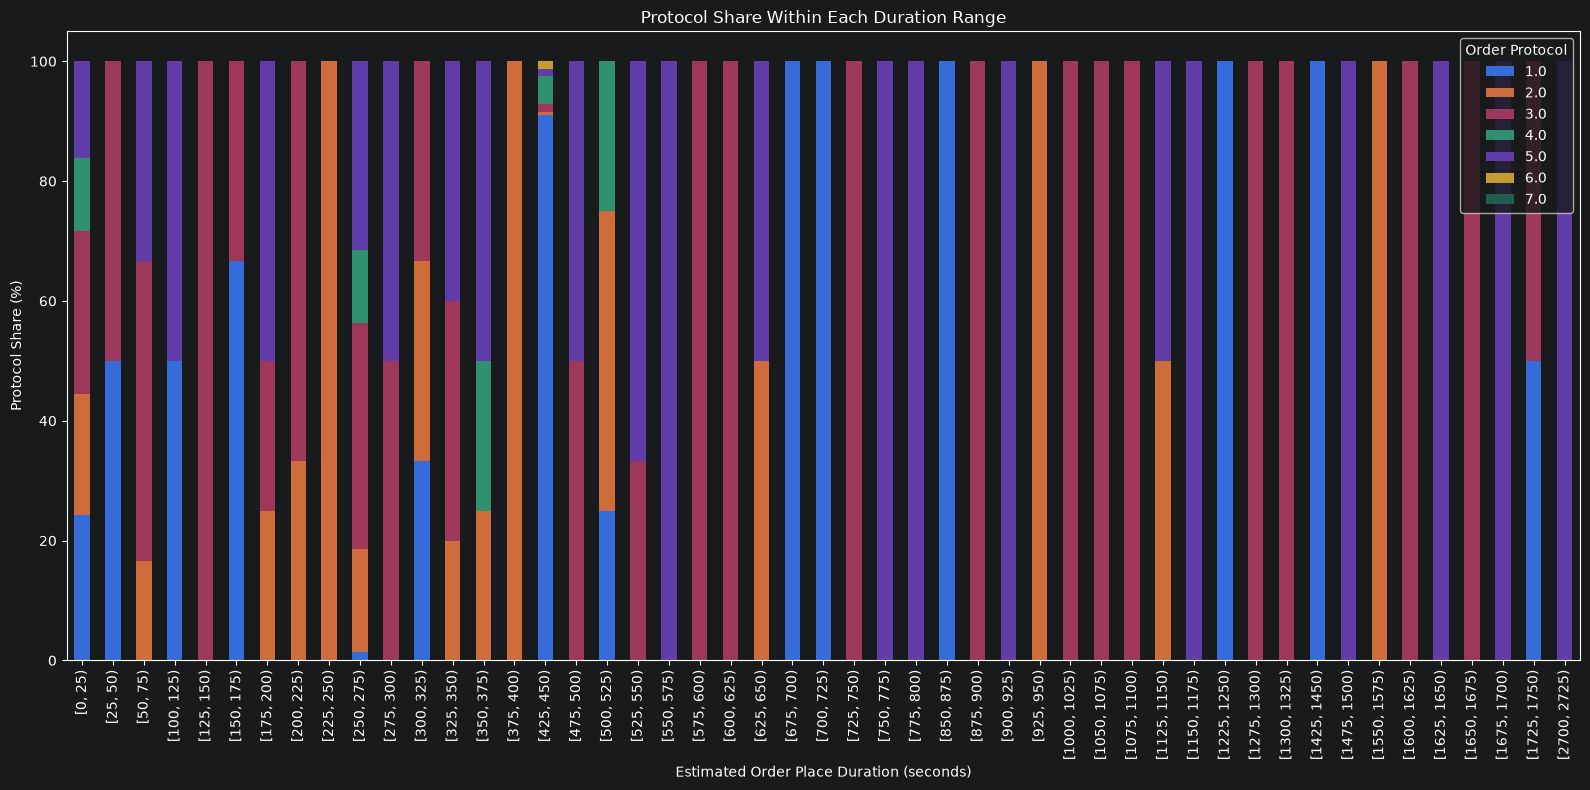

In [16]:
duration_protocol_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8)
)

plt.xlabel("Estimated Order Place Duration (seconds)")
plt.ylabel("Protocol Share (%)")
plt.title("Protocol Share Within Each Duration Range")
plt.legend(title="Order Protocol")

plt.tight_layout()
plt.show()

In [17]:
dominance = pd.DataFrame({
    "dominant_protocol": duration_protocol.idxmax(axis=1),
    "dominant_count": duration_protocol.max(axis=1),
    "total_orders": duration_protocol.sum(axis=1),
})

dominance["dominance_pct"] = (
    dominance["dominant_count"] / dominance["total_orders"] * 100
)

dominance

,dominant_protocol,dominant_count,total_orders,dominance_pct
duration_bin,,,,
"[0, 25)",3.0,27,99,27.272727
"[25, 50)",1.0,1,2,50.000000
"[50, 75)",3.0,3,6,50.000000
"[100, 125)",1.0,1,2,50.000000
"[125, 150)",3.0,1,1,100.000000
"[150, 175)",1.0,2,3,66.666667
"[175, 200)",5.0,2,4,50.000000
"[200, 225)",3.0,2,3,66.666667
"[225, 250)",2.0,1,1,100.000000


In [18]:
# Reproducibility
np.random.seed(42)

# Create 25-second bins
bins = np.arange(
    0,
    df["estimated_order_place_duration"].max() + 25,
    25
)

df["duration_bin"] = pd.cut(
    df["estimated_order_place_duration"],
    bins=bins,
    right=False
)

# Rows where protocol is known
known = df.dropna(subset=["order_protocol"])

# P(protocol | duration_bin)
protocol_probs = pd.crosstab(
    known["duration_bin"],
    known["order_protocol"],
    normalize="index"
)

# Fill missing protocols probabilistically
missing_mask = df["order_protocol"].isna()

for bin_value in df.loc[missing_mask, "duration_bin"].dropna().unique():

    mask = (
        missing_mask
        & (df["duration_bin"] == bin_value)
    )

    if bin_value in protocol_probs.index:

        probs = protocol_probs.loc[bin_value]

        protocols = probs.index.to_numpy()
        probabilities = probs.values

        df.loc[mask, "order_protocol"] = np.random.choice(
            protocols,
            size=mask.sum(),
            p=probabilities
        )

# Remove temporary bin column
df.drop(columns="duration_bin", inplace=True)

In [19]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 196895
Null Rows in market_id: 986
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 4749
Null Rows in order_protocol: 0
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16218
Null Rows in total_busy_dashers: 16218
Null Rows in total_outstanding_orders: 16218
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 0


## Impute `market_id` using per-store mode

In [20]:
store_market = (
    df.dropna(subset=["market_id"])
      .groupby("store_id")["market_id"]
      .nunique()
)

store_market.value_counts()

market_id
1    3827
2    1586
3     705
4     354
5     180
6      87
Name: count, dtype: int64

In [21]:
# Confidence per store
store_market_dist = (
    df.dropna(subset=["market_id"])
      .groupby(["store_id", "market_id"])
      .size()
      .groupby(level=0)
      .transform(lambda x: x / x.sum())
)

store_market_confidence = (store_market_dist.groupby(level=0).max())

missing_mask = df["market_id"].isna()
confidence = df.loc[missing_mask, "store_id"].map(store_market_confidence)
confidence.describe()

count    983.000000
mean       0.959961
std        0.036290
min        0.500000
25%        0.949321
50%        0.963351
75%        0.978456
max        1.000000
Name: store_id, dtype: float64

In [22]:
# --- Impute market_id using per-store mode ---

# Flag rows that will be imputed
df["market_id_imputed"] = df["market_id"].isna()

# Mode market_id per store, computed from known rows only
store_mode_market = (
    df.dropna(subset=["market_id"])
      .groupby("store_id")["market_id"]
      .agg(lambda x: x.mode().iloc[0])
)

# Map store -> mode market, fill only missing values
df["market_id"] = df["market_id"].fillna(df["store_id"].map(store_mode_market))

print(f"Remaining nulls in market_id: {df['market_id'].isnull().sum()}")
df = df.dropna(subset=["market_id"])

Remaining nulls in market_id: 3


In [23]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 196892
Null Rows in market_id: 0
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 4748
Null Rows in order_protocol: 0
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16217
Null Rows in total_busy_dashers: 16217
Null Rows in total_outstanding_orders: 16217
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 0
Null Rows in market_id_imputed: 0


## Impute `store_primary_category` using per-store mode

In [24]:
# How many distinct categories does each store have (among known rows)?
store_category_count = (
    df.dropna(subset=["store_primary_category"])
      .groupby("store_id")["store_primary_category"]
      .nunique()
)

store_category_count.value_counts().sort_index()

store_primary_category
1     3568
2     1398
3      640
4      333
5      201
6      140
7       70
8       61
9       33
10      29
11      25
12      15
13      20
14       6
15       7
16       8
18       4
19       1
20       2
21       2
22       2
24       1
Name: count, dtype: int64

In [25]:
missing_category_stores = df.loc[df["store_primary_category"].isna(), "store_id"]

resolvable = missing_category_stores.isin(store_category_count.index)
print(f"Missing rows with a resolvable store_id: {resolvable.sum()} / {len(missing_category_stores)}")

Missing rows with a resolvable store_id: 3886 / 4748


In [26]:
# Confidence per store
store_category_dist = (
    df.dropna(subset=["store_primary_category"])
      .groupby(["store_id", "store_primary_category"])
      .size()
      .groupby(level=0)
      .transform(lambda x: x / x.sum())
)

store_category_confidence = store_category_dist.groupby(level=0).max()

missing_mask = df["store_primary_category"].isna()
confidence = df.loc[missing_mask, "store_id"].map(store_category_confidence)
confidence.describe()

count    3886.000000
mean        0.686358
std         0.326238
min         0.166667
25%         0.333333
50%         0.929936
75%         1.000000
max         1.000000
Name: store_id, dtype: float64

In [27]:
df["store_category_imputed"] = df["store_primary_category"].isna()

# Stores with exactly one distinct known category
single_category_stores = store_category_count[store_category_count == 1].index

store_mode_category = (
    df.dropna(subset=["store_primary_category"])
      .groupby("store_id")["store_primary_category"]
      .agg(lambda x: x.mode().iloc[0])
)

missing_mask = df["store_primary_category"].isna()

# Only trust the mode for single-category stores; else "unknown"
resolved = df.loc[missing_mask, "store_id"].map(
    lambda sid: store_mode_category[sid] if sid in single_category_stores else "unknown"
)

# Stats before filling
filled_from_store = (resolved != "unknown").sum()
set_to_unknown = (resolved == "unknown").sum()

df.loc[missing_mask, "store_primary_category"] = resolved

print(f"Previously missing: {missing_mask.sum()}")
print(f"Filled from store category: {filled_from_store}")
print(f"Set to 'unknown': {set_to_unknown}")
print(f"Remaining nulls: {df['store_primary_category'].isnull().sum()}")

Previously missing: 4748
Filled from store category: 1134
Set to 'unknown': 3614
Remaining nulls: 0


In [28]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 196892
Null Rows in market_id: 0
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 0
Null Rows in order_protocol: 0
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16217
Null Rows in total_busy_dashers: 16217
Null Rows in total_outstanding_orders: 16217
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 0
Null Rows in market_id_imputed: 0
Null Rows in store_category_imputed: 0


## Impute `total_onshift_dashers`, `total_busy_dashers`, and `total_outstanding_orders` using per-market-hour median

In [29]:
null_mask = df["total_onshift_dashers"].isna()

In [30]:
# total_onshift_dashers - market relationship
df.loc[null_mask, "market_id"].value_counts(normalize=True)

market_id
6.0    0.852069
3.0    0.100142
2.0    0.016526
4.0    0.013258
1.0    0.012333
5.0    0.005673
Name: proportion, dtype: float64

<Figure size 1400x500 with 0 Axes>

Text(0.5, 1.0, 'Daily Null Rate: Dasher Availability Fields')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Fraction of rows null')

(array([16358., 16375., 16389., 16405., 16419., 16436., 16450., 16467.,
        16481.]),
 [Text(16358.0, 0, '2014-10-15'),
  Text(16375.0, 0, '2014-11-01'),
  Text(16389.0, 0, '2014-11-15'),
  Text(16405.0, 0, '2014-12-01'),
  Text(16419.0, 0, '2014-12-15'),
  Text(16436.0, 0, '2015-01-01'),
  Text(16450.0, 0, '2015-01-15'),
  Text(16467.0, 0, '2015-02-01'),
  Text(16481.0, 0, '2015-02-15')])

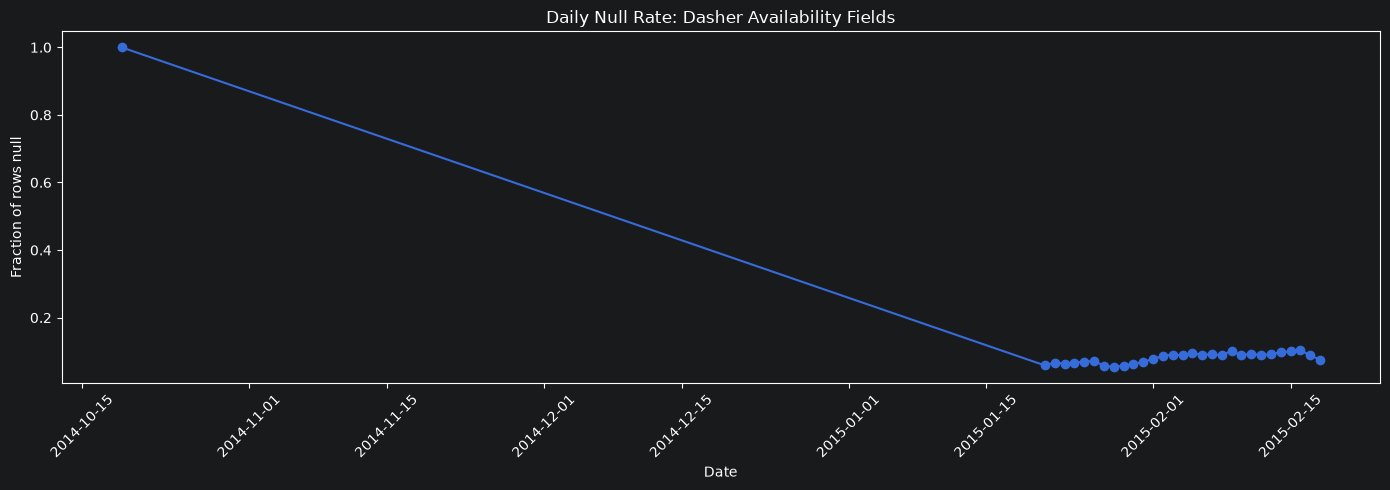

In [31]:
# total_onshift_dashers - hour relationship
daily_null_counts = (
    df.loc[null_mask, "created_at"]
      .dt.date
      .value_counts()
      .sort_index()
)

daily_total_counts = df["created_at"].dt.date.value_counts().sort_index()

daily_null_rate = (daily_null_counts / daily_total_counts).fillna(0)

plt.figure(figsize=(14, 5))
plt.plot(daily_null_rate.index, daily_null_rate.values, marker="o")
plt.title("Daily Null Rate: Dasher Availability Fields")
plt.xlabel("Date")
plt.ylabel("Fraction of rows null")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["hour"] = df["created_at"].dt.hour

dasher_cols = ["total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders"]

for col in dasher_cols:
    df[f"{col}_imputed"] = df[col].isna()
    group_median = df.groupby(["market_id", "hour"])[col].transform("median")
    df[col] = df[col].fillna(group_median)

df = df.drop(columns=["hour"])


for col in dasher_cols:
    print(col, df[col].isnull().sum())

df = df.dropna(subset=["total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders"])

total_onshift_dashers 2
total_busy_dashers 2
total_outstanding_orders 2


In [33]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 196890
Null Rows in market_id: 0
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 0
Null Rows in order_protocol: 0
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 0
Null Rows in total_busy_dashers: 0
Null Rows in total_outstanding_orders: 0
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 0
Null Rows in market_id_imputed: 0
Null Rows in store_category_imputed: 0
Null Rows in total_onshift_dashers_imputed: 0
Null Rows in total_busy_dashers_imputed: 0
Null Rows in total_outstanding_orders_imputed: 0


## EDA

In [34]:
# --- Target Calculation & Outlier Audit ---

df["total_delivery_duration"] = (
    df["actual_delivery_time"] - df["created_at"]
).dt.total_seconds()

# Percentile check
percentiles = [0, 0.001, 0.01, 0.5, 0.99, 0.999, 1.0]
df["total_delivery_duration"].quantile(percentiles)

0.000        101.000
0.001        846.889
0.010       1152.000
0.500       2661.000
0.990       6476.110
0.999       9942.444
1.000    8516859.000
Name: total_delivery_duration, dtype: float64

In [35]:
print(f"Total rows before outlier removal: {len(df)}")

# Remove anomalies: non-positive or excessively long durations
df = df[
    (df["total_delivery_duration"] > 0) &
    (df["total_delivery_duration"] <= 7200)
]

print(f"Total rows after outlier removal: {len(df)}")
df["total_delivery_duration"].describe()

Total rows before outlier removal: 196890
Total rows after outlier removal: 195802


count    195802.000000
mean       2826.334639
std        1016.201281
min         101.000000
25%        2101.000000
50%        2654.000000
75%        3366.000000
max        7196.000000
Name: total_delivery_duration, dtype: float64

In [36]:
# --- Local US/Pacific Conversion ---

# created_at is currently naive UTC (per dataset docs) -> localize then convert
df["created_at_utc"] = df["created_at"].dt.tz_localize("UTC")
df["created_at_local"] = df["created_at_utc"].dt.tz_convert("US/Pacific")

# Recompute hour and day-of-week using LOCAL time
df["order_hour"] = df["created_at_local"].dt.hour
df["order_day_of_week"] = df["created_at_local"].dt.dayofweek  # 0=Monday

df = df.drop(columns=["created_at_utc"])
df[["created_at", "created_at_local", "order_hour", "order_day_of_week"]].sample(5)

,created_at,created_at_local,order_hour,order_day_of_week
14362,2015-01-25 01:18:15,2015-01-24 17:18:15-08:00,17,5
127425,2015-02-05 20:13:52,2015-02-05 12:13:52-08:00,12,3
79552,2015-02-12 02:24:55,2015-02-11 18:24:55-08:00,18,2
162567,2015-01-31 01:33:42,2015-01-30 17:33:42-08:00,17,4
170232,2015-02-07 03:39:54,2015-02-06 19:39:54-08:00,19,4


In [37]:
print(df.dtypes)

market_id                                                          float64
created_at                                                  datetime64[ns]
actual_delivery_time                                        datetime64[ns]
store_id                                                             int64
store_primary_category                                              object
order_protocol                                                     float64
total_items                                                          int64
subtotal                                                             int64
num_distinct_items                                                   int64
min_item_price                                                       int64
max_item_price                                                       int64
total_onshift_dashers                                              float64
total_busy_dashers                                                 float64
total_outstanding_orders 

<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='market_id'>

Text(0.5, 1.0, 'Median Delivery Duration by Market')

Text(0.5, 0, 'Market ID')

Text(0, 0.5, 'Median Duration (seconds)')

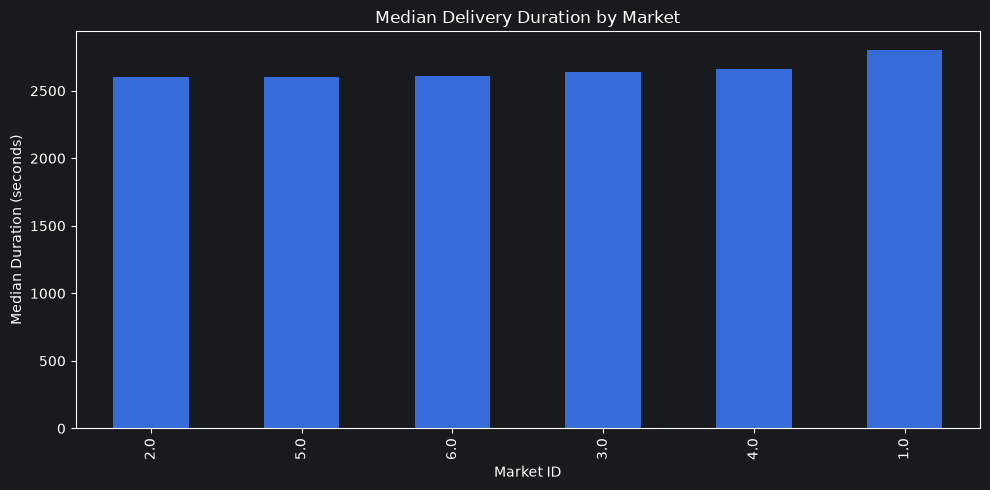

In [38]:
market_median = df.groupby("market_id")["total_delivery_duration"].median().sort_values()

plt.figure(figsize=(10, 5))
market_median.plot(kind="bar")
plt.title("Median Delivery Duration by Market")
plt.xlabel("Market ID")
plt.ylabel("Median Duration (seconds)")
plt.tight_layout()
plt.show()

count    195802.000000
mean       2826.334639
std        1016.201281
min         101.000000
25%        2101.000000
50%        2654.000000
75%        3366.000000
max        7196.000000
Name: total_delivery_duration, dtype: float64

<Figure size 1200x500 with 0 Axes>

(array([1.000e+00, 1.000e+00, 1.000e+00, 3.000e+00, 4.000e+00, 3.000e+00,
        1.400e+01, 2.000e+01, 2.900e+01, 6.700e+01, 1.350e+02, 2.360e+02,
        3.430e+02, 5.110e+02, 7.610e+02, 1.021e+03, 1.393e+03, 1.749e+03,
        2.134e+03, 2.502e+03, 3.155e+03, 3.472e+03, 4.028e+03, 4.515e+03,
        4.835e+03, 5.267e+03, 5.640e+03, 5.969e+03, 6.075e+03, 6.229e+03,
        6.377e+03, 6.272e+03, 6.561e+03, 6.401e+03, 6.218e+03, 6.102e+03,
        5.952e+03, 5.785e+03, 5.463e+03, 5.146e+03, 4.995e+03, 4.877e+03,
        4.535e+03, 4.281e+03, 4.034e+03, 3.658e+03, 3.506e+03, 3.384e+03,
        3.087e+03, 2.988e+03, 2.756e+03, 2.456e+03, 2.369e+03, 2.201e+03,
        2.014e+03, 1.887e+03, 1.783e+03, 1.575e+03, 1.557e+03, 1.396e+03,
        1.283e+03, 1.150e+03, 1.116e+03, 1.011e+03, 8.990e+02, 8.630e+02,
        7.990e+02, 7.250e+02, 6.770e+02, 6.540e+02, 5.970e+02, 5.400e+02,
        4.610e+02, 4.770e+02, 4.030e+02, 4.210e+02, 3.360e+02, 3.520e+02,
        3.280e+02, 2.970e+02, 2.460e+0

Text(0.5, 1.0, 'Distribution of Total Delivery Duration (seconds)')

Text(0.5, 0, 'Duration (seconds)')

Text(0, 0.5, 'Count')

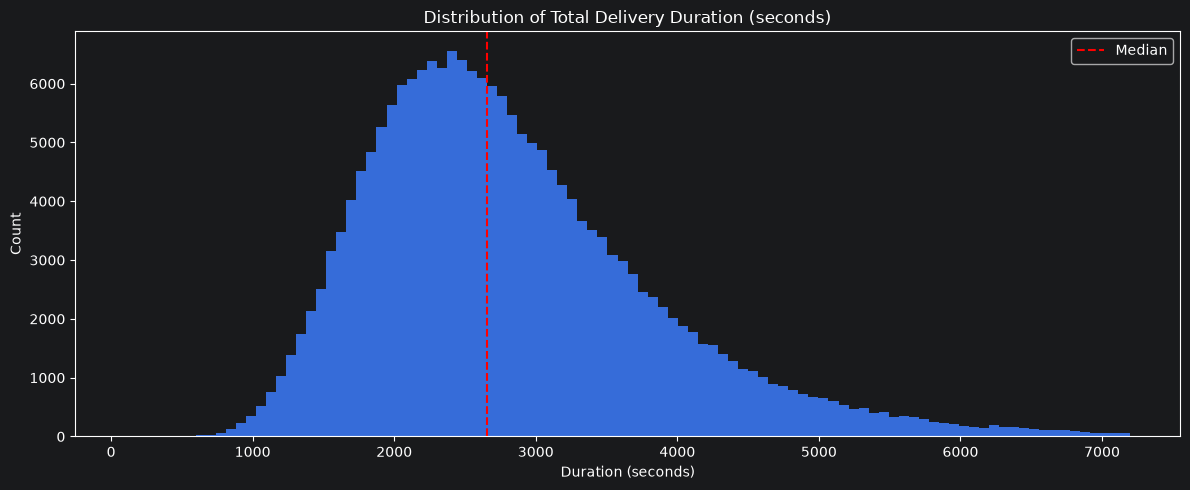

In [39]:
df["total_delivery_duration"].describe()

plt.figure(figsize=(12, 5))
plt.hist(df["total_delivery_duration"], bins=100)
plt.axvline(df["total_delivery_duration"].median(), color="red", linestyle="--", label="Median")
plt.title("Distribution of Total Delivery Duration (seconds)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Median Delivery Duration by Local Hour of Day')

Text(0.5, 0, 'Hour (US/Pacific)')

Text(0, 0.5, 'Median Duration (seconds)')

([<matplotlib.axis.XTick at 0x112accc80>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

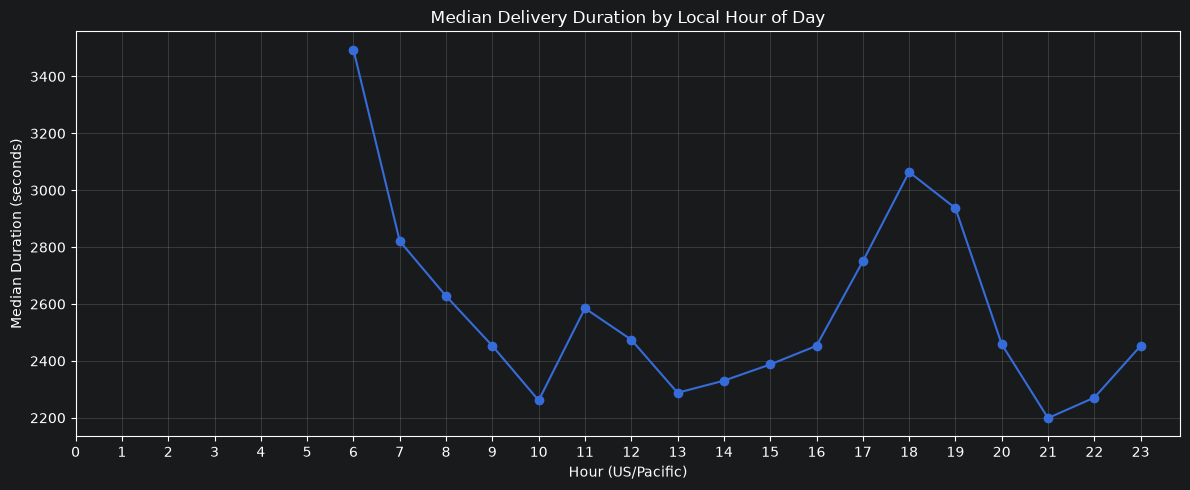

In [40]:
hourly_median = df.groupby("order_hour")["total_delivery_duration"].median()

plt.figure(figsize=(12, 5))
plt.plot(hourly_median.index, hourly_median.values, marker="o")
plt.title("Median Delivery Duration by Local Hour of Day")
plt.xlabel("Hour (US/Pacific)")
plt.ylabel("Median Duration (seconds)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
df["order_hour"].value_counts().sort_index()

order_hour
6        36
7       523
8      2078
9      3388
10     5049
11    13339
12    15372
13    11372
14     8780
15     8110
16    12622
17    28035
18    36575
19    26839
20    15184
21     7076
22     1415
23        9
Name: count, dtype: int64

order_day_of_week
0    24479
1    23844
2    25003
3    26617
4    32915
5    32708
6    30236
Name: count, dtype: int64


<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='order_day_of_week'>

Text(0.5, 1.0, 'Median Delivery Duration by Day of Week (0=Monday)')

Text(0.5, 0, 'Day of Week')

Text(0, 0.5, 'Median Duration (seconds)')

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6')])

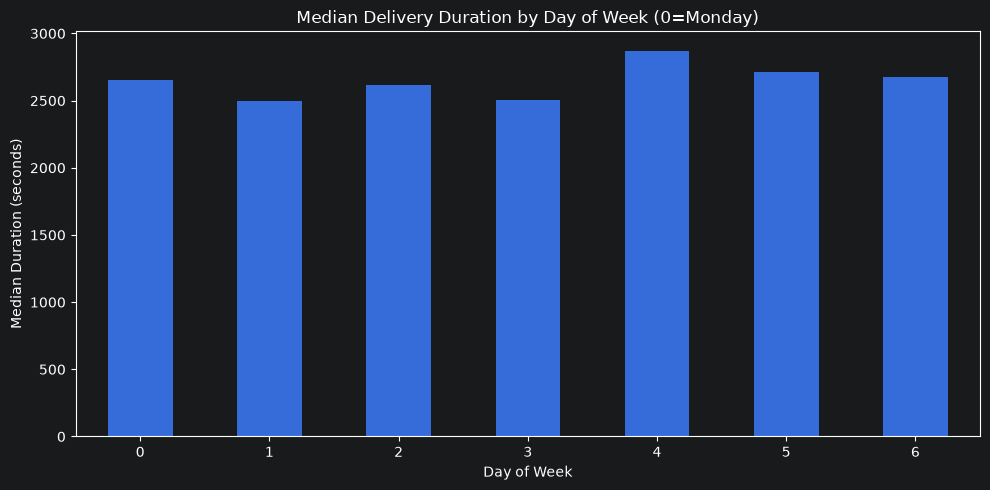

In [42]:
dow_median = df.groupby("order_day_of_week")["total_delivery_duration"].median()
dow_counts = df["order_day_of_week"].value_counts().sort_index()

print(dow_counts)

plt.figure(figsize=(10, 5))
dow_median.sort_index().plot(kind="bar")
plt.title("Median Delivery Duration by Day of Week (0=Monday)")
plt.xlabel("Day of Week")
plt.ylabel("Median Duration (seconds)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

([<matplotlib.axis.XTick at 0x11334e090>,
 [Text(0, 0, 'total_delivery_duration'),
  Text(1, 0, 'total_items'),
  Text(2, 0, 'subtotal'),
  Text(3, 0, 'num_distinct_items'),
  Text(4, 0, 'min_item_price'),
  Text(5, 0, 'max_item_price'),
  Text(6, 0, 'total_onshift_dashers'),
  Text(7, 0, 'total_busy_dashers'),
  Text(8, 0, 'total_outstanding_orders'),
  Text(9, 0, 'estimated_order_place_duration'),
  Text(10, 0, 'estimated_store_to_consumer_driving_duration'),
  Text(11, 0, 'order_hour'),
  Text(12, 0, 'order_day_of_week')])

([<matplotlib.axis.YTick at 0x11334d3d0>,
 [Text(0, 0, 'total_delivery_duration'),
  Text(0, 1, 'total_items'),
  Text(0, 2, 'subtotal'),
  Text(0, 3, 'num_distinct_items'),
  Text(0, 4, 'min_item_price'),
  Text(0, 5, 'max_item_price'),
  Text(0, 6, 'total_onshift_dashers'),
  Text(0, 7, 'total_busy_dashers'),
  Text(0, 8, 'total_outstanding_orders'),
  Text(0, 9, 'estimated_order_place_duration'),
  Text(0, 10, 'estimated_store_to_consumer_driving_duration'),
  Text(0, 11, 'order_hour'),
  Text(0, 12, 'order_day_of_week')])

Text(0, 0, '1.00')

Text(1, 0, '0.12')

...

Text(9, 12, '0.02')

Text(10, 12, '0.01')

Text(11, 12, '-0.01')

Text(12, 12, '1.00')

Text(0.5, 1.0, 'Correlation Heatmap: Numeric Features vs Target')

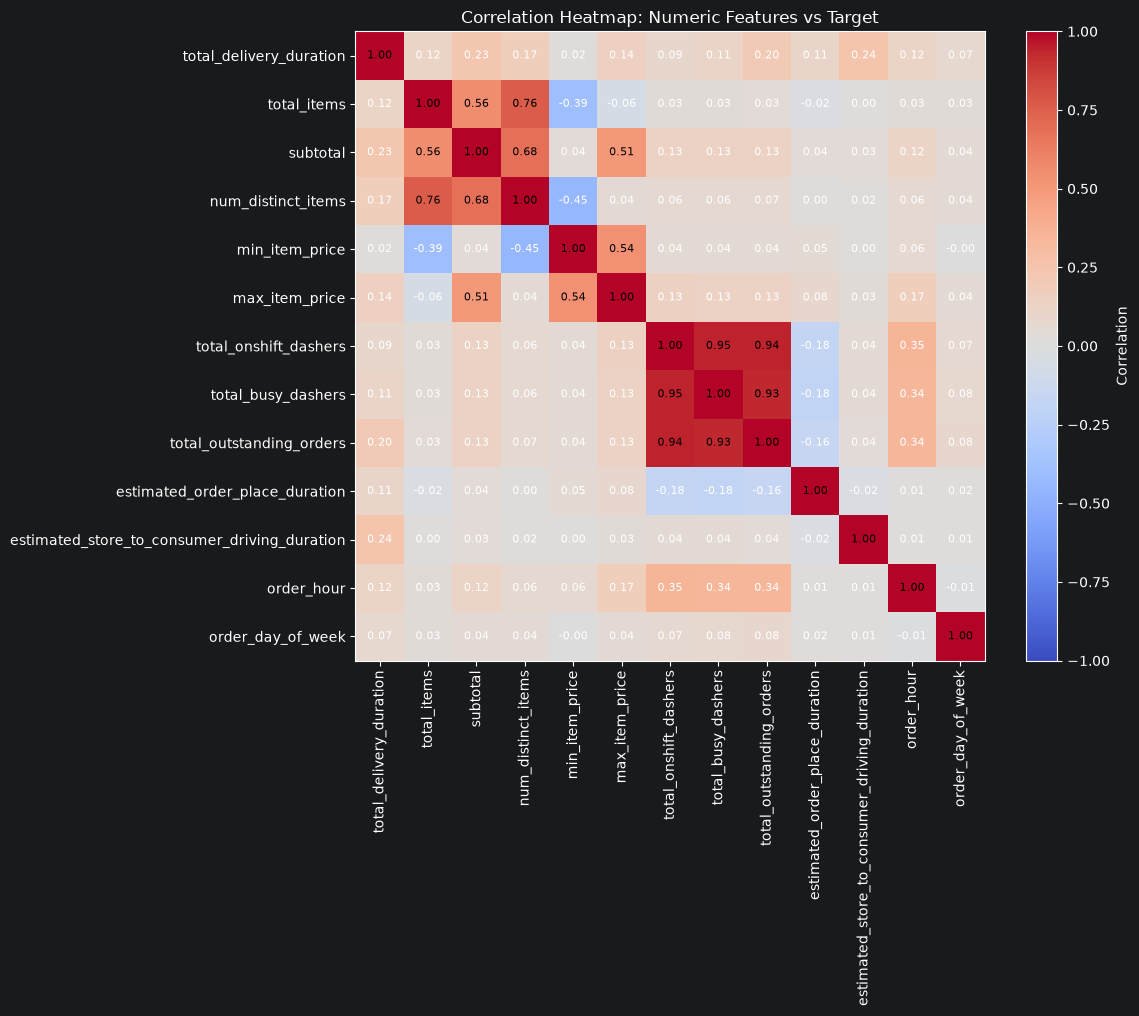

In [43]:
numeric_cols = [
    "total_delivery_duration",
    "total_items",
    "subtotal",
    "num_distinct_items",
    "min_item_price",
    "max_item_price",
    "total_onshift_dashers",
    "total_busy_dashers",
    "total_outstanding_orders",
    "estimated_order_place_duration",
    "estimated_store_to_consumer_driving_duration",
    "order_hour",
    "order_day_of_week",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)

# annotate values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                  color="black" if abs(corr.iloc[i, j]) > 0.5 else "white", fontsize=8)

plt.title("Correlation Heatmap: Numeric Features vs Target")
plt.tight_layout()
plt.show()

In [44]:
df.to_csv('../data/processed/cleaned_data.csv', index=False)